
Se_R1s(r) =
+390.6593 * exp(-34.7125 r)
+272.7963 * r * exp(-29.3786 r)
-1.5447 * r * exp(-15.7400 r)
+1460.5596 * r^2 * exp(-42.7575 r)
-0.6540 * r^2 * exp(-11.7494 r)
-0.0037 * r^2 * exp(-8.0222 r)
-0.0022 * r^2 * exp(-5.6528 r)
+49.5396 * r^3 * exp(-18.3237 r)
+0.0000 * r^3 * exp(-3.4106 r)
+0.0000 * r^3 * exp(-2.2896 r)
+0.0000 * r^3 * exp(-1.5845 r)

Se_R2s(r) =
-122.2466 * exp(-34.7125 r)
-1197.6622 * r * exp(-29.3786 r)
+1113.5483 * r * exp(-15.7400 r)
-7.3276 * r^2 * exp(-42.7575 r)
+307.3567 * r^2 * exp(-11.7494 r)
-5.4164 * r^2 * exp(-8.0222 r)
+0.6952 * r^2 * exp(-5.6528 r)
+6631.7246 * r^3 * exp(-18.3237 r)
-0.0155 * r^3 * exp(-3.4106 r)
+0.0014 * r^3 * exp(-2.2896 r)
-0.0001 * r^3 * exp(-1.5845 r)

Se_R3s(r) =
-48.1040 * exp(-34.7125 r)
-556.2236 * r * exp(-29.3786 r)
+523.7405 * r * exp(-15.7400 r)
-117.4568 * r^2 * exp(-42.7575 r)
+297.2486 * r^2 * exp(-11.7494 r)
-361.5041 * r^2 * exp(-8.0222 r)
-115.1130 * r^2 * exp(-5.6528 r)
+6803.3459 * r^3 * exp(-18.3237 r)
-0.231

/tmp/ipykernel_2591/3811764430.py:147: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)


Norm 1s = 0.9999920113669748
Norm 2s = 0.9999983185468962
Norm 2p = 1.0000011591435285
Norm 3s = 1.0000005034639625
Norm 3p = 0.9999997918827424
Norm 3d = 0.999999903663015
Norm 4s = 0.9999996447525069
Norm 4p = 1.0000002289900058
           Q  J_1s_one_electron  J_2s_one_electron  J_3s_one_electron  \
0       0.00           0.025545           0.093924       2.468520e-01   
1       0.05           0.025545           0.093916       2.466801e-01   
2       0.10           0.025544           0.093891       2.461653e-01   
3       0.15           0.025544           0.093849       2.453100e-01   
4       0.20           0.025542           0.093790       2.441183e-01   
...      ...                ...                ...                ...   
1996   99.80           0.000027           0.000003       4.799745e-07   
1997   99.85           0.000027           0.000003       4.786178e-07   
1998   99.90           0.000027           0.000003       4.772655e-07   
1999   99.95           0.000027        

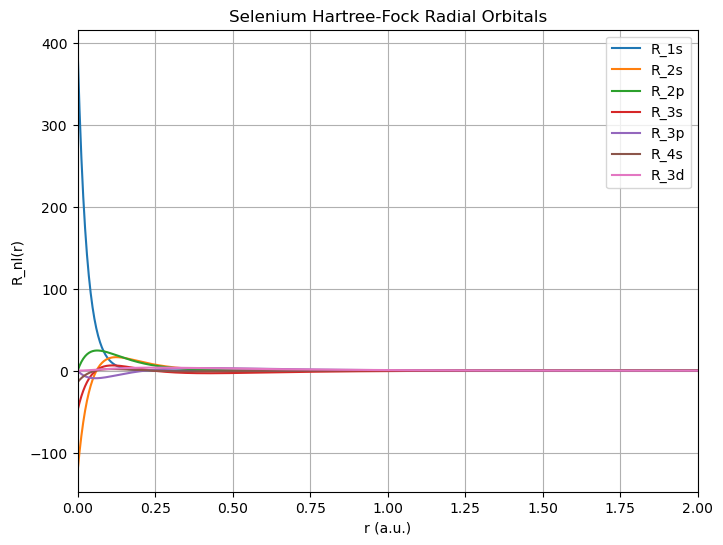

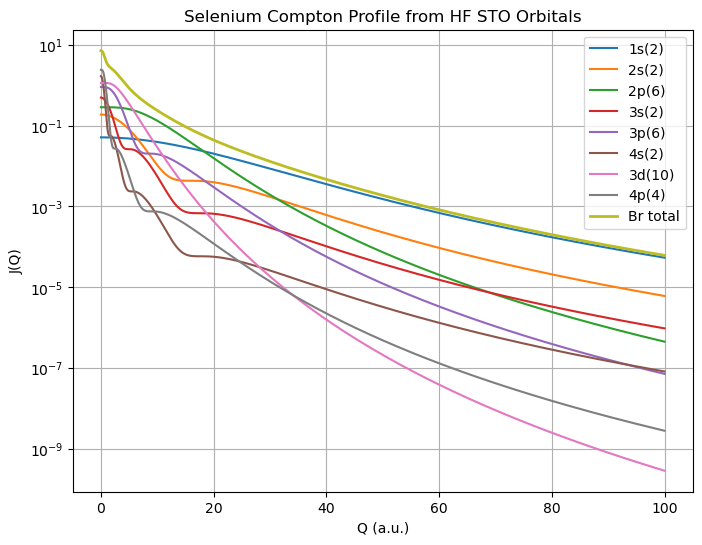

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Selenium Hartree-Fock STO data
# Se: 1s2 2s2 2p6 3s2 3p6 3d10 4s2 4p4
# Format: (n_j, Z_j, C_j)
# =====================================================

selenium_1s = [
    (1, 34.7125,  0.955079),
    (2, 29.3786,  0.050500),
    (2, 15.7400, -0.001361),
    (3, 42.7575,  0.006777),
    (3, 11.7494, -0.000279),
    (3,  8.0222, -0.000006),
    (3,  5.6528, -0.000012),
    (4, 18.3237,  0.000911),
    (4,  3.4106,  0.000000),
    (4,  2.2896,  0.000001),
    (4,  1.5845,  0.000000),
]

selenium_2s = [
    (1, 34.7125, -0.298867),
    (2, 29.3786, -0.221711),
    (2, 15.7400,  0.981133),
    (3, 42.7575, -0.000034),
    (3, 11.7494,  0.131114),
    (3,  8.0222, -0.008785),
    (3,  5.6528,  0.003839),
    (4, 18.3237,  0.121953),
    (4,  3.4106, -0.000550),
    (4,  2.2896,  0.000298),
    (4,  1.5845, -0.000102),
]

selenium_3s = [
    (1, 34.7125, -0.117604),
    (2, 29.3786, -0.102968),
    (2, 15.7400,  0.461461),
    (3, 42.7575, -0.000545),
    (3, 11.7494,  0.126802),
    (3,  8.0222, -0.586337),
    (3,  5.6528, -0.635716),
    (4, 18.3237,  0.125109),
    (4,  3.4106, -0.008229),
    (4,  2.2896,  0.001502),
    (4,  1.5845, -0.000557),
]

selenium_4s = [
    (1, 34.7125, -0.034379),
    (2, 29.3786, -0.030932),
    (2, 15.7400,  0.138682),
    (3, 42.7575, -0.000114),
    (3, 11.7494,  0.037692),
    (3,  8.0222, -0.197476),
    (3,  5.6528, -0.240944),
    (4, 18.3237,  0.042941),
    (4,  3.4106,  0.430881),
    (4,  2.2896,  0.532759),
    (4,  1.5845,  0.178817),
]

selenium_2p = [
    (2, 35.2165,  0.064815),
    (2, 13.3691,  0.719004),
    (3, 28.9584,  0.144057),
    (3, 10.0638,  0.026166),
    (3,  6.6718,  0.000188),
    (3,  4.7438,  0.000765),
    (4, 23.4246,  0.097238),
    (4,  3.0297, -0.000071),
    (4,  1.9218, -0.000023),
    (4,  1.2451, -0.000011),
]

selenium_3p = [
    (2, 35.2165, -0.008694),
    (2, 13.3691, -0.474977),
    (3, 28.9584, -0.009411),
    (3, 10.0638,  0.181185),
    (3,  6.6718,  0.636415),
    (3,  4.7438,  0.354144),
    (4, 23.4246,  0.013955),
    (4,  3.0297,  0.005093),
    (4,  1.9218,  0.000316),
    (4,  1.2451,  0.000151),
]

selenium_4p = [
    (2, 35.2165, -0.001192),
    (2, 13.3691, -0.125022),
    (3, 28.9584,  0.000418),
    (3, 10.0638,  0.054010),
    (3,  6.6718,  0.173494),
    (3,  4.7438,  0.093637),
    (4, 23.4246,  0.006379),
    (4,  3.0297, -0.358802),
    (4,  1.9218, -0.538721),
    (4,  1.2451, -0.242599),
]

selenium_3d = [
    (3, 17.6906,  0.016536),
    (3,  9.8167,  0.244834),
    (3,  6.1051,  0.448354),
    (3,  3.9379,  0.358333),
    (3,  2.4892,  0.047754),
]
# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Krypton radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, selenium_1s)
R2s = R_nl(r, selenium_2s)
R3s = R_nl(r, selenium_3s)
R4s = R_nl(r, selenium_4s)
R2p = R_nl(r, selenium_2p)
R3p = R_nl(r, selenium_3p)
R4p = R_nl(r, selenium_4p)
R3d = R_nl(r, selenium_3d)

print_R_formula(selenium_1s, "Se_R1s")
print_R_formula(selenium_2s, "Se_R2s")
print_R_formula(selenium_3s, "Se_R3s")
print_R_formula(selenium_4s, "Se_R4s")
print_R_formula(selenium_2p, "Se_R2p")
print_R_formula(selenium_3p, "Se_R3p")
print_R_formula(selenium_3d, "Se_R3d")
print_R_formula(selenium_4p, "Se_R4p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_4p = chi_p(p, r, R4p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_4p, J_4p = calculate_J(p, chi_4p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))
print("Norm 4p =", np.trapezoid(I_4p, p))

# Krypton has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(2) 4p(5)
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 10*J_3d + 2*J_4s + 4*J_4p

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_3s_one_electron": J_3s,
    "J_2p_one_electron": J_2p,
    "J_3p_one_electron": J_3p,
    "J_3d_one_electron": J_3d,
    "J_4s_one_electron": J_4s,
    "J_4p_one electron": J_4p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(6)": 6*J_2p,
    "J_3s(2)": 2*J_3s,
    "J_3p(6)": 6*J_3p,
    "J_4s(1)": 2*J_4s,
    "J_3d(10)": 10*J_3d,
    "J_4p(4)": 4*J_4p,
    "J_total_Se": J_total
    })
print(table)
table.to_csv("Selenium__STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Selenium Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 10*J_3d, label="3d(10)")
plt.plot(Q, 4*J_4p, label="4p(4)")
plt.plot(Q, J_total, label="Br total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Selenium Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()